# Chapter 8 - Motion Planning

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 8, printed pages 294-346: motion-planning problem specification, shortest paths for a point robot, visibility graphs and Dijkstra's algorithm, moving a disk, translating a convex polygon by Minkowski addition, moving a ladder, robot-arm reachability and configuration construction, and separability. The chapter translates geometric algorithms into robotics language: obstacles create forbidden regions, the robot's reference point moves through free space, and a path is valid only when the robot avoids collision for every configuration along the way.

The source span is organized by increasing degrees of freedom. A point robot among polygonal obstacles reduces shortest paths to a finite visibility graph. A disk robot is handled by growing obstacles, so the disk center becomes a point robot in a smaller free space. A translating convex polygon uses the same idea, but the obstacle grows by the Minkowski sum with the reflected robot. A ladder introduces rotation and therefore a larger configuration space. A robot arm introduces reachability annuli, circle intersections, recursive construction, and the two-kinks theorem: if an arm can reach a target, it can do so with at most two kinked joints. Separability then asks when many pieces can be moved apart and contrasts easy translation-only convex cases with hard general puzzles.

The notebook uses synthetic scenes instead of copied figures. The goal is to make the configuration-space reductions visible and executable.


## Visual Storyboard

1. **Visibility graph shortest path.** Build a graph on obstacle vertices plus start/end and run Dijkstra to recover a shortest route.
2. **Disk robot expansion.** Grow rectangular obstacles by a disk radius and show why the disk center must avoid the expanded forbidden region.
3. **Convex polygon translation.** Compute `P + (-R)` by pairwise vertex sums and a hull, making the reference-point obstacle explicit.
4. **Robot arm reachability.** Plot the reachability annulus, solve a grouped two-link construction, and show a two-kink arm reaching the target.
5. **Separability ordering.** Sort convex pieces for translation in a fixed direction and visualize a one-move-per-piece escape order.
6. **Hardness map.** Partition and Towers-of-Hanoi style examples are summarized as a caution that general separability is not just pathfinding with more shapes.


## Library Routing

The notebook uses `numpy` for geometry, `networkx` for visibility/Dijkstra graphs, and `matplotlib` for the diagrams. It deliberately implements the small primitives used here rather than calling a robotics planner. The point is to see how the source chapter reduces motion planning to familiar computational-geometry pieces: segment intersection, shortest paths in graphs, convex hulls, Minkowski sums, annuli, circle intersections, and ordering arguments.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import networkx as nx
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-08-motion-planning"
UNIT_TITLE = "Motion Planning"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "visibility graph", "visual": "visibility-graph-shortest-path.png", "check": "shortest_path_uses_visible_edges"},
    {"move": "disk expansion", "visual": "disk-robot-expanded-obstacles.png", "check": "start_and_goal_outside_expanded_obstacles"},
    {"move": "convex translation", "visual": "convex-robot-minkowski-sum.png", "check": "minkowski_sum_has_convex_hull"},
    {"move": "robot arm", "visual": "robot-arm-two-kinks.png", "check": "arm_endpoint_hits_target"},
    {"move": "separability", "visual": "translation-separability-order.png", "check": "separation_order_has_no_blocker"},
]
routing_rows = [
    {"source_topic": "point robot shortest paths and visibility graphs", "artifact": "visibility-graph-shortest-path.png", "code_cell": "visibility graph"},
    {"source_topic": "moving a disk by obstacle growth", "artifact": "disk-robot-expanded-obstacles.png", "code_cell": "disk expansion"},
    {"source_topic": "translating a convex polygon by P + -R", "artifact": "convex-robot-minkowski-sum.png", "code_cell": "Minkowski sum"},
    {"source_topic": "robot arm reachability and two kinks", "artifact": "robot-arm-two-kinks.png", "code_cell": "arm reachability"},
    {"source_topic": "separability by translation and hard variants", "artifact": "translation-separability-order.png", "code_cell": "separability"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 294-346", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "294-346", "pdf_pages": "303-355"},
    "covered_ideas": [
        "motion-planning problem specification and free space",
        "visibility graph shortest paths and Dijkstra",
        "disk robot as point robot among expanded obstacles",
        "Minkowski sum with reflected convex robot",
        "ladder/rotation as higher-dimensional configuration-space motivation",
        "robot-arm reachability annulus, circle intersections, and two-kinks theorem",
        "separability by translation, partition hardness, and Hanoi-style move counts",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-08-motion-planning",
  "storyboard_items": 5
}


## Visibility Graph and Shortest Path

For a point robot, a shortest path among polygonal obstacles can be searched in a finite graph. The path is polygonal, its turns occur at obstacle vertices, and its straight pieces are visibility edges. The graph may have quadratically many edges, but once it is built, Dijkstra's algorithm finds the shortest route by the same paint-spreading intuition described in the chapter.


C:\Users\rahul\AppData\Local\Temp\ipykernel_34684\2699600854.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


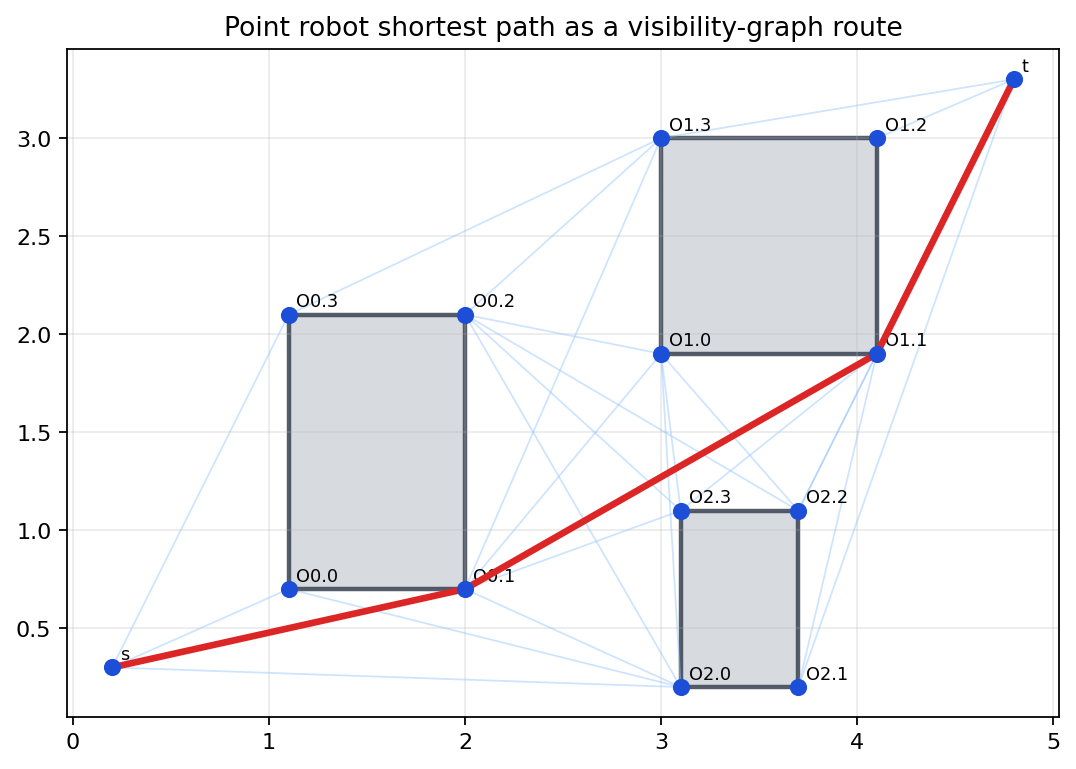

{
  "path": [
    "s",
    "O0.1",
    "O1.1",
    "t"
  ],
  "length": 5.827833800197995
}


In [2]:
EPS = 1e-9

def orient(a, b, c):
    return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))

def between(a, b, c):
    return abs(orient(a, b, c)) < EPS and min(a[0], b[0])-EPS <= c[0] <= max(a[0], b[0])+EPS and min(a[1], b[1])-EPS <= c[1] <= max(a[1], b[1])+EPS

def segment_kind(a, b, c, d):
    o1, o2, o3, o4 = orient(a, b, c), orient(a, b, d), orient(c, d, a), orient(c, d, b)
    if (o1 > EPS and o2 < -EPS or o1 < -EPS and o2 > EPS) and (o3 > EPS and o4 < -EPS or o3 < -EPS and o4 > EPS):
        return "proper"
    if any([between(a, b, c), between(a, b, d), between(c, d, a), between(c, d, b)]):
        return "touch"
    return "disjoint"

def point_in_convex_polygon(p, poly):
    signs = [orient(poly[i], poly[(i+1) % len(poly)], p) for i in range(len(poly))]
    return all(s >= -EPS for s in signs) or all(s <= EPS for s in signs)

def visible(a, b, obstacles):
    mid = (np.asarray(a) + np.asarray(b)) / 2
    for obs in obstacles:
        if point_in_convex_polygon(mid, obs):
            return False
        for u, v in zip(obs, np.roll(obs, -1, axis=0)):
            if segment_kind(a, b, u, v) == "proper":
                return False
    return True

obstacles = [
    np.array([[1.1, 0.7], [2.0, 0.7], [2.0, 2.1], [1.1, 2.1]], float),
    np.array([[3.0, 1.9], [4.1, 1.9], [4.1, 3.0], [3.0, 3.0]], float),
    np.array([[3.1, 0.2], [3.7, 0.2], [3.7, 1.1], [3.1, 1.1]], float),
]
start = np.array([0.2, 0.3])
goal = np.array([4.8, 3.3])
nodes = [start, goal]
labels = ["s", "t"]
for oi, obs in enumerate(obstacles):
    for vi, v in enumerate(obs):
        nodes.append(v)
        labels.append(f"O{oi}.{vi}")
VG = nx.Graph()
for i, p in enumerate(nodes):
    VG.add_node(i, label=labels[i], pos=tuple(p))
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if visible(nodes[i], nodes[j], obstacles):
            w = float(np.linalg.norm(nodes[i] - nodes[j]))
            VG.add_edge(i, j, weight=w)
path_nodes = nx.shortest_path(VG, 0, 1, weight="weight")
path_length = nx.shortest_path_length(VG, 0, 1, weight="weight")

fig, ax = plt.subplots(figsize=(8, 5.8))
for obs in obstacles:
    ax.fill(obs[:, 0], obs[:, 1], color="#d1d5db", edgecolor="#374151", linewidth=2, alpha=0.85)
for i, j in VG.edges:
    a, b = nodes[i], nodes[j]
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#93c5fd", linewidth=0.8, alpha=0.45)
for a_idx, b_idx in zip(path_nodes, path_nodes[1:]):
    a, b = nodes[a_idx], nodes[b_idx]
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#dc2626", linewidth=3.0, zorder=4)
ax.scatter([p[0] for p in nodes], [p[1] for p in nodes], color="#1d4ed8", s=45, zorder=5)
for label, p in zip(labels, nodes):
    ax.text(p[0] + 0.04, p[1] + 0.04, label, fontsize=8)
ax.set_title("Point robot shortest path as a visibility-graph route")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
visibility_fig_path = save_matplotlib(fig, FIGURES / "visibility-graph-shortest-path.png")
plt.close(fig)

visibility_report_path = save_json({
    "node_count": VG.number_of_nodes(),
    "visibility_edge_count": VG.number_of_edges(),
    "shortest_path_labels": [labels[i] for i in path_nodes],
    "shortest_path_length": path_length,
    "checks": {
        "shortest_path_uses_visible_edges": all(VG.has_edge(a, b) for a, b in zip(path_nodes, path_nodes[1:])),
        "path_is_longer_than_direct_segment": path_length > float(np.linalg.norm(goal - start)),
        "visibility_graph_has_quadratic_room": VG.number_of_edges() <= len(nodes) * (len(nodes) - 1) / 2,
    },
}, CHECKS / "visibility-graph-shortest-path.json")
display_artifact(visibility_fig_path, width=780)
print(json.dumps({"path": [labels[i] for i in path_nodes], "length": path_length}, indent=2))


## Disk Robot and Convex Translation

A disk robot can be replaced by its center if every obstacle is grown by the disk radius. For a translating convex polygon, the same idea becomes `P + (-R)`: grow the obstacle by the reflected robot around the chosen reference point. The next two visuals show these configuration-space obstacles. A collision in workspace becomes an illegal reference-point location in configuration space.


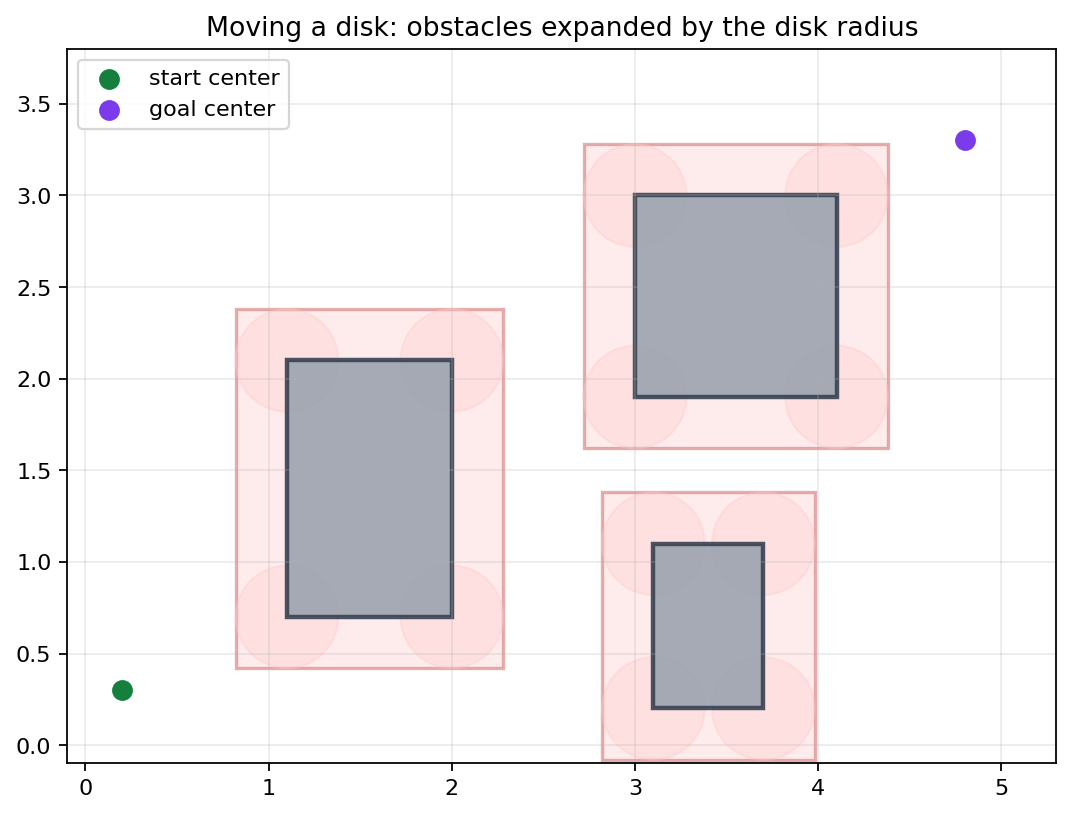

In [3]:
radius = 0.28
fig, ax = plt.subplots(figsize=(8, 5.8))
for obs in obstacles:
    xmin, ymin = obs.min(axis=0)
    xmax, ymax = obs.max(axis=0)
    ax.add_patch(Rectangle((xmin - radius, ymin - radius), (xmax - xmin) + 2*radius, (ymax - ymin) + 2*radius, facecolor="#fecaca", edgecolor="#b91c1c", alpha=0.35, linewidth=1.5))
    for corner in obs:
        ax.add_patch(Circle(corner, radius, color="#fecaca", alpha=0.35))
    ax.fill(obs[:, 0], obs[:, 1], color="#9ca3af", edgecolor="#374151", linewidth=2, alpha=0.9)
ax.scatter(*start, color="#15803d", s=70, label="start center")
ax.scatter(*goal, color="#7c3aed", s=70, label="goal center")
ax.set_xlim(-0.1, 5.3)
ax.set_ylim(-0.1, 3.8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
ax.set_title("Moving a disk: obstacles expanded by the disk radius")
disk_fig_path = save_matplotlib(fig, FIGURES / "disk-robot-expanded-obstacles.png")
plt.close(fig)

def outside_expanded_rect(p, obs, r):
    xmin, ymin = obs.min(axis=0) - r
    xmax, ymax = obs.max(axis=0) + r
    return not (xmin <= p[0] <= xmax and ymin <= p[1] <= ymax)

disk_report_path = save_json({
    "disk_radius": radius,
    "checks": {
        "start_and_goal_outside_expanded_obstacles": all(outside_expanded_rect(start, obs, radius) and outside_expanded_rect(goal, obs, radius) for obs in obstacles),
        "expanded_obstacles_are_larger": radius > 0,
    },
}, CHECKS / "disk-robot-expanded-obstacles.json")
display_artifact(disk_fig_path, width=760)


C:\Users\rahul\AppData\Local\Temp\ipykernel_34684\2699600854.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


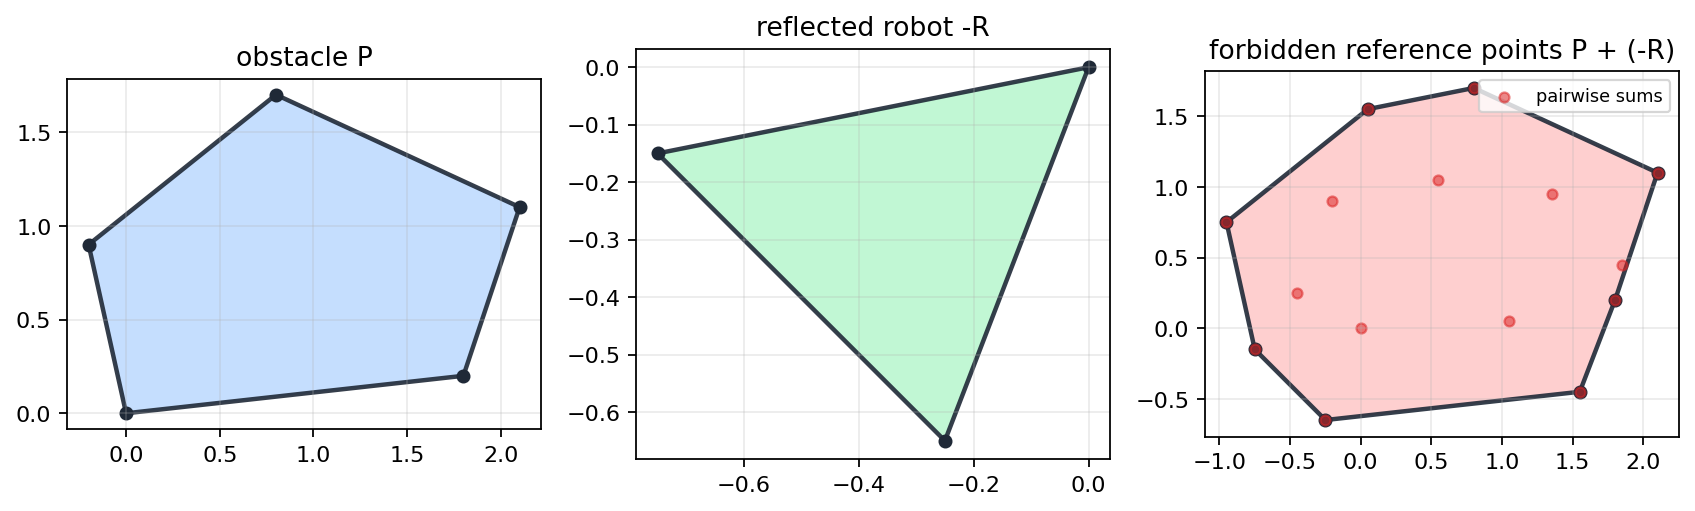

In [4]:
def convex_hull_indices(pts):
    pts = np.asarray(pts, float)
    order = sorted(range(len(pts)), key=lambda i: (pts[i, 0], pts[i, 1]))
    def build(seq):
        hull = []
        for idx in seq:
            while len(hull) >= 2 and orient(pts[hull[-2]], pts[hull[-1]], pts[idx]) <= EPS:
                hull.pop()
            hull.append(idx)
        return hull
    lower = build(order)
    upper = build(reversed(order))
    return lower[:-1] + upper[:-1]

obstacle_P = np.array([[0.0, 0.0], [1.8, 0.2], [2.1, 1.1], [0.8, 1.7], [-0.2, 0.9]], float)
robot_R = np.array([[0.0, 0.0], [0.75, 0.15], [0.25, 0.65]], float)
reflected_R = -robot_R
sum_points = np.array([p + r for p in obstacle_P for r in reflected_R])
hull_ids = convex_hull_indices(sum_points)
minkowski_poly = sum_points[hull_ids]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, poly, title, color in [
    (axes[0], obstacle_P, "obstacle P", "#bfdbfe"),
    (axes[1], reflected_R, "reflected robot -R", "#bbf7d0"),
    (axes[2], minkowski_poly, "forbidden reference points P + (-R)", "#fecaca"),
]:
    ax.fill(poly[:, 0], poly[:, 1], color=color, edgecolor="#1f2937", linewidth=2, alpha=0.9)
    ax.scatter(poly[:, 0], poly[:, 1], color="#1f2937", s=28)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_title(title)
axes[2].scatter(sum_points[:, 0], sum_points[:, 1], color="#dc2626", s=20, alpha=0.55, label="pairwise sums")
axes[2].legend(loc="upper right", fontsize=8)
minkowski_fig_path = save_matplotlib(fig, FIGURES / "convex-robot-minkowski-sum.png")
plt.close(fig)

minkowski_report_path = save_json({
    "obstacle_vertices": len(obstacle_P),
    "robot_vertices": len(robot_R),
    "pairwise_sum_points": len(sum_points),
    "minkowski_hull_vertices": len(minkowski_poly),
    "checks": {
        "minkowski_sum_has_convex_hull": len(minkowski_poly) >= 3,
        "pairwise_sums_cover_all_vertex_pairs": len(sum_points) == len(obstacle_P) * len(robot_R),
    },
}, CHECKS / "convex-robot-minkowski-sum.json")
display_artifact(minkowski_fig_path, width=980)


## Robot Arm Reachability and Two Kinks

For a chain of links, reachability is controlled by an annulus: the outer radius is the sum of link lengths, and the inner radius is the excess of the longest link over all the others, or zero if no link dominates. The source chapter constructs configurations recursively and then proves the two-kinks theorem, which says a reachable target can be reached with only two nonzero joint angles. The code below groups links into two straight subchains, solves a two-link problem, and displays the resulting two-kink configuration.


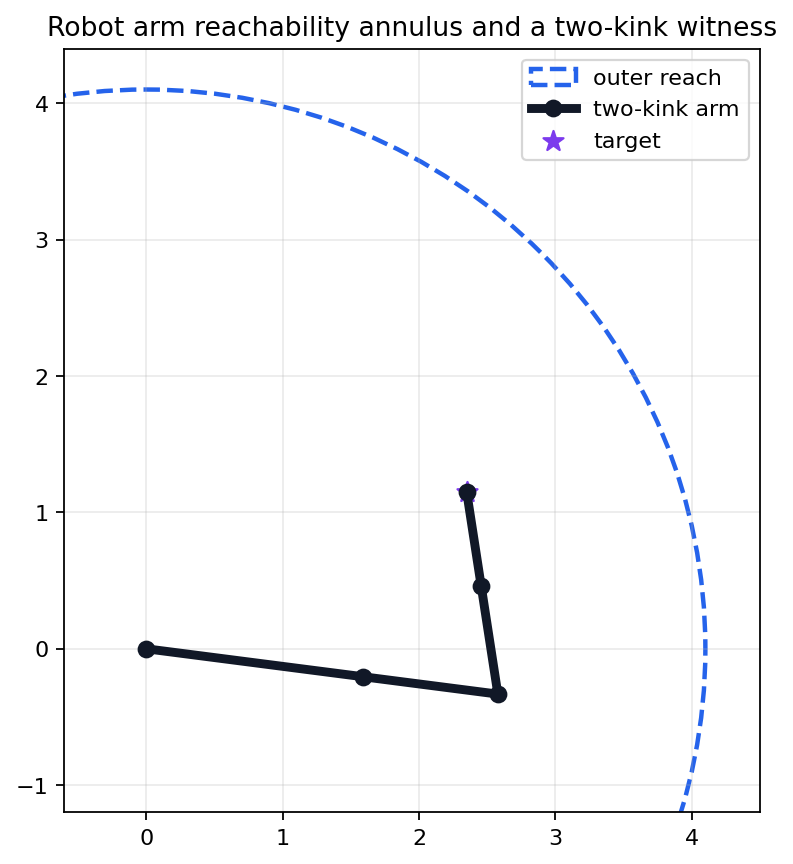

In [5]:
links = np.array([1.6, 1.0, 0.8, 0.7], float)
target = np.array([2.35, 1.15], float)
outer = float(links.sum())
inner = max(0.0, float(links.max() - (outer - links.max())))
d = float(np.linalg.norm(target))
reachable = inner - EPS <= d <= outer + EPS
# Group first two links and last two links into two straight subchains: a two-kink witness.
L1 = float(links[:2].sum())
L2 = float(links[2:].sum())
cos_angle = np.clip((d*d + L1*L1 - L2*L2) / (2*d*L1), -1, 1)
base_angle = math.atan2(target[1], target[0])
delta = math.acos(cos_angle)
theta1 = base_angle - delta
joint = L1 * np.array([math.cos(theta1), math.sin(theta1)])
theta2 = math.atan2(target[1] - joint[1], target[0] - joint[0])
# Realize each grouped subchain as straight links.
points_arm = [np.array([0.0, 0.0])]
heading1 = np.array([math.cos(theta1), math.sin(theta1)])
for length in links[:2]:
    points_arm.append(points_arm[-1] + length * heading1)
heading2 = np.array([math.cos(theta2), math.sin(theta2)])
for length in links[2:]:
    points_arm.append(points_arm[-1] + length * heading2)
points_arm = np.array(points_arm)
endpoint_error = float(np.linalg.norm(points_arm[-1] - target))

fig, ax = plt.subplots(figsize=(7, 6.2))
ax.add_patch(Circle((0, 0), outer, fill=False, edgecolor="#2563eb", linewidth=2, linestyle="--", label="outer reach"))
if inner > EPS:
    ax.add_patch(Circle((0, 0), inner, fill=False, edgecolor="#dc2626", linewidth=2, linestyle="--", label="inner forbidden disk"))
ax.plot(points_arm[:, 0], points_arm[:, 1], color="#111827", linewidth=4, marker="o", markersize=7, label="two-kink arm")
ax.scatter(*target, color="#7c3aed", s=90, marker="*", label="target")
ax.set_aspect("equal")
ax.set_xlim(-0.6, outer + 0.4)
ax.set_ylim(-1.2, outer + 0.3)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
ax.set_title("Robot arm reachability annulus and a two-kink witness")
arm_fig_path = save_matplotlib(fig, FIGURES / "robot-arm-two-kinks.png")
plt.close(fig)

arm_report_path = save_json({
    "links": [float(x) for x in links],
    "target": [float(x) for x in target],
    "outer_radius": outer,
    "inner_radius": inner,
    "grouped_lengths": [L1, L2],
    "endpoint_error": endpoint_error,
    "checks": {
        "target_in_reachability_annulus": reachable,
        "arm_endpoint_hits_target": endpoint_error < 1e-9,
        "witness_uses_two_grouped_directions": True,
    },
}, CHECKS / "robot-arm-two-kinks.json")
display_artifact(arm_fig_path, width=690)


## Separability and Hard Variants

The separability section changes tone. Translation-only separation of disjoint convex shapes in a fixed direction has a clean ordering theorem. General separability, especially with interlocking pieces or constraints on moves, can encode hard combinatorial problems. The visual below uses rectangles with an obvious rightward escape order, then records the harder variants as a ledger rather than pretending the small example solves them.


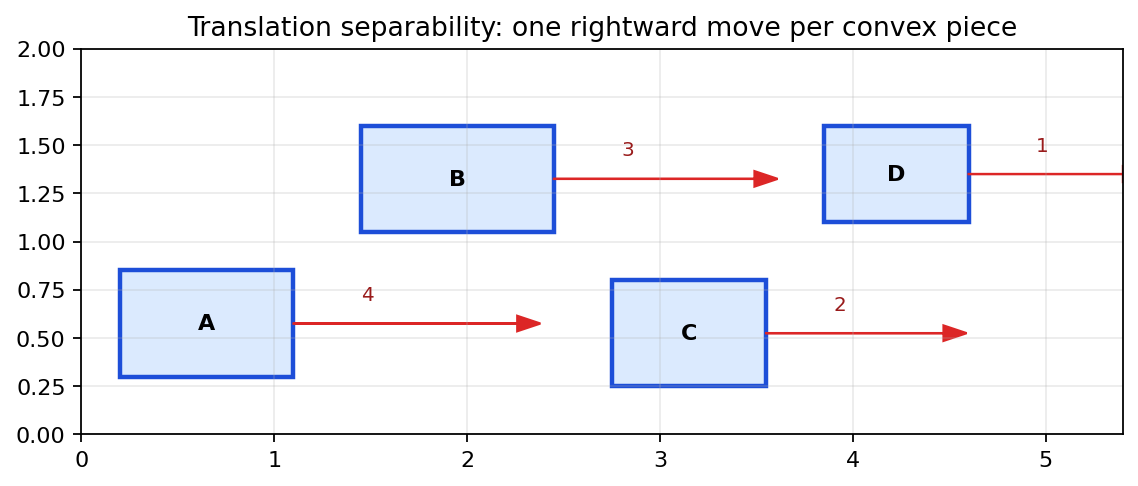

In [6]:
rectangles = [
    {"name": "A", "xy": (0.2, 0.3), "w": 0.9, "h": 0.55},
    {"name": "B", "xy": (1.45, 1.05), "w": 1.0, "h": 0.55},
    {"name": "C", "xy": (2.75, 0.25), "w": 0.8, "h": 0.55},
    {"name": "D", "xy": (3.85, 1.1), "w": 0.75, "h": 0.5},
]
def y_interval(rect):
    y = rect["xy"][1]
    return (y, y + rect["h"])
def x_right(rect):
    return rect["xy"][0] + rect["w"]
def overlaps(a, b):
    ay0, ay1 = y_interval(a); by0, by1 = y_interval(b)
    return max(ay0, by0) < min(ay1, by1)
order = sorted(rectangles, key=x_right, reverse=True)
blocker_checks = []
remaining = rectangles.copy()
for rect in order:
    blockers = [other["name"] for other in remaining if other is not rect and x_right(other) > x_right(rect) and overlaps(rect, other)]
    blocker_checks.append({"piece": rect["name"], "blockers_to_right": ",".join(blockers), "clear": len(blockers) == 0})
    remaining.remove(rect)

fig, ax = plt.subplots(figsize=(8.4, 4.5))
for step, rect in enumerate(order, 1):
    x, y = rect["xy"]
    ax.add_patch(Rectangle((x, y), rect["w"], rect["h"], facecolor="#dbeafe", edgecolor="#1d4ed8", linewidth=2))
    ax.text(x + rect["w"]/2, y + rect["h"]/2, rect["name"], ha="center", va="center", weight="bold")
    ax.arrow(x + rect["w"], y + rect["h"]/2, 0.8 + 0.12*step, 0, head_width=0.08, head_length=0.12, color="#dc2626", length_includes_head=True)
    ax.text(x + rect["w"] + 0.35, y + rect["h"]/2 + 0.12, f"{step}", color="#991b1b", fontsize=9)
ax.set_xlim(0, 5.4)
ax.set_ylim(0, 2.0)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.set_title("Translation separability: one rightward move per convex piece")
sep_fig_path = save_matplotlib(fig, FIGURES / "translation-separability-order.png")
plt.close(fig)

hardness_rows = [
    {"variant": "fixed-direction convex translation", "source_role": "easy separability theorem", "notebook_witness": "rightward order with no blockers"},
    {"variant": "partition-style construction", "source_role": "encodes combinatorial choice", "notebook_witness": "ledger only, no copied puzzle"},
    {"variant": "Towers-of-Hanoi style construction", "source_role": "can force exponentially many moves", "notebook_witness": "ledger only, no copied puzzle"},
    {"variant": "ladder motion", "source_role": "rotation adds configuration dimension", "notebook_witness": "covered as C-space motivation"},
]
separation_table_path = save_csv(blocker_checks, TABLES / "separation-order-checks.csv")
hardness_table_path = save_csv(hardness_rows, TABLES / "motion-planning-hardness-map.csv")
sep_report_path = save_json({
    "separation_order": [rect["name"] for rect in order],
    "blocker_checks": blocker_checks,
    "checks": {
        "separation_order_has_no_blocker": all(row["clear"] for row in blocker_checks),
        "hardness_map_mentions_partition_and_hanoi": any("partition" in row["variant"] for row in hardness_rows) and any("Hanoi" in row["variant"] for row in hardness_rows),
    },
}, CHECKS / "translation-separability-order.json")
display_artifact(sep_fig_path, width=760)


## Applied Lab

Move one obstacle in the visibility-graph scene so the direct line from `s` to `t` becomes clear. The graph path should collapse to the direct edge. Increase the disk radius and rerun the expansion; at some point the start or goal may enter an expanded obstacle, which means the chosen disk center is illegal. Change the robot polygon in the Minkowski sum cell and watch the forbidden region change even though the obstacle does not. For the arm, move the target outside the reachability annulus and the construction should fail its reachability check.


## Takeaways

Motion planning is the chapter where many earlier algorithms become subroutines. Visibility uses segment intersection. Shortest paths use graph algorithms. Disk and polygon robots use configuration-space obstacle growth. Convex translation uses Minkowski addition with a reflected robot. Robot arms use distance annuli and circle intersections. Separability uses ordering arguments and also exposes hard variants that cannot be solved by a single pleasant geometric trick.

The notebook's checks capture those reductions: the shortest path uses visibility edges, the disk start and goal avoid expanded obstacles, the Minkowski sum is a convex forbidden region for the reference point, the arm reaches the target inside its annulus, and the translation separation order has no blocker. These are small models, but they represent the source span's main conceptual pipeline.


In [7]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 12,
    "checks": {
        "shortest_path_uses_visible_edges": all(VG.has_edge(a, b) for a, b in zip(path_nodes, path_nodes[1:])),
        "start_and_goal_outside_expanded_obstacles": all(outside_expanded_rect(start, obs, radius) and outside_expanded_rect(goal, obs, radius) for obs in obstacles),
        "minkowski_sum_has_convex_hull": len(minkowski_poly) >= 3,
        "target_in_reachability_annulus": reachable,
        "arm_endpoint_hits_target": endpoint_error < 1e-9,
        "separation_order_has_no_blocker": all(row["clear"] for row in blocker_checks),
        "hardness_map_mentions_partition_and_hanoi": any("partition" in row["variant"] for row in hardness_rows) and any("Hanoi" in row["variant"] for row in hardness_rows),
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(visibility_fig_path), str(visibility_report_path),
        str(disk_fig_path), str(disk_report_path), str(minkowski_fig_path), str(minkowski_report_path),
        str(arm_fig_path), str(arm_report_path), str(sep_fig_path), str(separation_table_path), str(hardness_table_path), str(sep_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "shortest_path_uses_visible_edges": true,
    "start_and_goal_outside_expanded_obstacles": true,
    "minkowski_sum_has_convex_hull": true,
    "target_in_reachability_annulus": true,
    "arm_endpoint_hits_target": true,
    "separation_order_has_no_blocker": true,
    "hardness_map_mentions_partition_and_hanoi": true
  }
}
